# Statistical Analysis: Hypothesis Testing

**Analysis by:** Margionet
**Tools:** Python (pandas, scipy) + Excel

## Objective

This notebook performs a complete statistical analysis on a dataset, including:
- Data cleaning and exploration (EDA)
- Hypothesis testing: t-test, ANOVA, chi-square
- Clear interpretation of results
- Export of an executive summary to Excel

> **Note:** This notebook uses sample data. For your project, the data loading section is replaced with your actual dataset.


## 1. Required libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 2. Load data

Replace this cell with the client's actual dataset, for example:
```python
df = pd.read_excel("client_dataset.xlsx")
```
For now, we use simulated data to illustrate the full workflow.


In [2]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    "value": np.random.normal(15000, 4000, n),
    "group": np.random.choice(["A", "B", "C"], n),
    "region": np.random.choice(["North", "South"], n),
    "outcome": np.random.choice(["Yes", "No"], n, p=[0.2, 0.8]),
})

df.head()


,value,group,region,outcome
0,16986.856612,B,South,Yes
1,14446.942795,B,North,No
2,17590.754152,A,North,No
3,21092.119426,A,South,No
4,14063.386501,A,South,No


## 3. Exploratory Data Analysis (EDA)

Before applying statistical tests, we review the general structure of the data:
variable types, missing values, and basic descriptive statistics.


In [3]:
print("General info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df.describe()


General info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   value    200 non-null    float64
 1   group    200 non-null    str    
 2   region   200 non-null    str    
 3   outcome  200 non-null    str    
dtypes: float64(1), str(3)
memory usage: 6.4 KB

Missing values per column:
value      0
group      0
region     0
outcome    0
dtype: int64

Descriptive statistics:


,value
count,200.000000
mean,14836.916139
std,3724.015661
min,4521.019584
25%,12179.489300
50%,14983.232464
75%,17003.409892
max,25880.676666


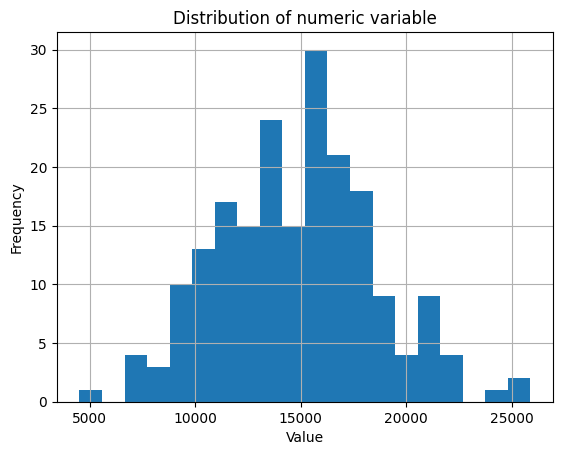

In [4]:
df["value"].hist(bins=20)
plt.title("Distribution of numeric variable")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


## 4. T-test: comparing two groups

The t-test evaluates whether the average of a numeric variable differs significantly
between **two** groups (in this example, North vs South).

- **Null hypothesis (H0):** there is no difference between the two group averages.
- **Alternative hypothesis (H1):** there is a significant difference.

If the p-value is below 0.05, H0 is rejected and the difference is considered significant.


In [5]:
group_north = df.loc[df["region"] == "North", "value"]
group_south = df.loc[df["region"] == "South", "value"]

t_stat, p_value_t = stats.ttest_ind(group_north, group_south)

print(f"t = {t_stat:.3f}, p-value = {p_value_t:.4f}")
if p_value_t < 0.05:
    print("→ Statistically significant difference between North and South (p < 0.05)")
else:
    print("→ No significant difference between North and South (p >= 0.05)")


t = -0.964, p-value = 0.3361
→ No significant difference between North and South (p >= 0.05)


## 5. ANOVA: comparing three or more groups

ANOVA (Analysis of Variance) extends the t-test logic to **three or more groups**
(in this example, groups A, B and C). It evaluates whether at least one group
differs significantly from the rest.

- **H0:** all groups have the same average.
- **H1:** at least one group differs significantly.


In [6]:
group_a = df.loc[df["group"] == "A", "value"]
group_b = df.loc[df["group"] == "B", "value"]
group_c = df.loc[df["group"] == "C", "value"]

f_stat, p_value_anova = stats.f_oneway(group_a, group_b, group_c)

print(f"F = {f_stat:.3f}, p-value = {p_value_anova:.4f}")
if p_value_anova < 0.05:
    print("→ At least one group differs significantly from the others (p < 0.05)")
else:
    print("→ No significant differences between groups (p >= 0.05)")


F = 0.364, p-value = 0.6952
→ No significant differences between groups (p >= 0.05)


## 6. Chi-square: association between categorical variables

The chi-square test evaluates whether there is a significant association between
two categorical variables (in this example, group vs outcome).

- **H0:** the two variables are independent (no association).
- **H1:** there is a significant association between them.


In [7]:
contingency_table = pd.crosstab(df["group"], df["outcome"])
print("Contingency table:")
print(contingency_table)

chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nchi2 = {chi2:.3f}, dof = {dof}, p-value = {p_value_chi2:.4f}")
if p_value_chi2 < 0.05:
    print("→ Significant association between group and outcome (p < 0.05)")
else:
    print("→ No significant association (p >= 0.05)")


Contingency table:
outcome  No  Yes
group           
A        65    9
B        56   14
C        41   15

chi2 = 4.499, dof = 2, p-value = 0.1054
→ No significant association (p >= 0.05)


## 7. Conclusions

Plain-language summary of the main findings (to be completed based on the client's
actual dataset results). For example:

- No significant difference in average value was found between regions.
- Groups A, B and C do not show significant differences among themselves.
- No significant association was found between group and observed outcome.


## 8. Export summary to Excel

An Excel file is generated with the summary of all tests performed,
ready to share with the client without needing to open the notebook.


In [8]:
summary = pd.DataFrame({
    "Test": ["T-test (North vs South)", "ANOVA (Groups A/B/C)", "Chi-square (Group vs Outcome)"],
    "Statistic": [t_stat, f_stat, chi2],
    "p-value": [p_value_t, p_value_anova, p_value_chi2],
    "Significant (p<0.05)": [p_value_t < 0.05, p_value_anova < 0.05, p_value_chi2 < 0.05],
    "Interpretation": [
        "Significant difference" if p_value_t < 0.05 else "No significant difference",
        "At least one group differs" if p_value_anova < 0.05 else "No differences between groups",
        "Significant association" if p_value_chi2 < 0.05 else "No significant association",
    ]
})

summary.to_excel("statistical_summary.xlsx", index=False)
print("Summary exported to statistical_summary.xlsx")
summary


Summary exported to statistical_summary.xlsx


,Test,Statistic,p-value,Significant (p<0.05),Interpretation
0,T-test (North vs South),-0.964218,0.336113,False,No significant difference
1,ANOVA (Groups A/B/C),0.364194,0.695223,False,No differences between groups
2,Chi-square (Group vs Outcome),4.499362,0.105433,False,No significant association
